# Mix of thermal and CR gas

In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from scipy.constants import k as k_B_SI
from matplotlib.colors import LogNorm

# Boltzmann constant in cgs: erg / K
k_B = k_B_SI * 1e7
k_B = 1.380649e-16  # erg K^-1

# seconds per Myr
Myr = 1e6 * 365.25 * 24 * 3600

from astropy import units as u, constants  as c

pc = c.pc.cgs.value
kB  = c.k_B.cgs.value
Msun = c.M_sun.cgs.value
G = c.G.cgs.value
Myr = u.Myr.to("s")
mp = c.m_p.cgs.value

## simulation data
load the SILCC data set we used before

In [2]:
# load SILCC data cube

with open('../sim-data/SILCC_hdf5_plt_cnt_3000-uniform-cube-N256-full.pkl', 'rb') as handle:
    data = pickle.load(handle)
recent_SNe = np.loadtxt("../sim-data/recent_SNe.txt")

N = data["n"].shape[0]
data.keys()
N

256

# CR models
these CR energy models are simply copied from the gamma problem

In [3]:
# definitions
EV_PER_CC_TO_ERG_PER_CM3 = 1.602176634e-12

def ecr_uniform(shape, ecr_eVcc=1.0):
    return np.full(shape, ecr_eVcc * EV_PER_CC_TO_ERG_PER_CM3)

def ecr_stratified(shape, z_pc, ecr0_eVcc=1.0, H_pc=1000.0):

    profile = (
        ecr0_eVcc
        * EV_PER_CC_TO_ERG_PER_CM3
        * np.exp(-np.abs(z_pc)/H_pc)
    )

    return np.broadcast_to(
        profile[None, None, :],
        shape
    )

def add_gaussian_blobs(
    ecr,
    x_pc,
    y_pc,
    z_pc,
    sn_list,
    amp_eVcc=1.0,
    sigma_pc=20.0,
):
    """
    Add 3D Gaussian point sources to an existing CR energy-density field.

    Parameters
    ----------
    ecr : ndarray, shape (Nx, Ny, Nz)
        CR energy density in erg cm^-3.
    x_pc, y_pc, z_pc : 1D arrays
        Cell-center coordinates in parsecs.
    sn_list : iterable
        Source positions as (x0, y0, z0), in parsecs.
    amp_eVcc : float
        Peak amplitude of each Gaussian in eV cm^-3.
    sigma_pc : float
        Gaussian standard deviation in parsecs.

    Returns
    -------
    out : ndarray
        Field with the Gaussian sources added.
    """
    out = np.array(ecr, dtype=float, copy=True)

    if out.shape != (len(x_pc), len(y_pc), len(z_pc)):
        raise ValueError(
            f"ecr has shape {out.shape}, but expected "
            f"{(len(x_pc), len(y_pc), len(z_pc))}"
        )

    if sigma_pc <= 0:
        raise ValueError("sigma_pc must be positive.")

    amp = amp_eVcc * EV_PER_CC_TO_ERG_PER_CM3

    # Reshape the coordinates for 3D broadcasting.
    x = np.asarray(x_pc)[:, None, None]  # shape (Nx, 1, 1)
    y = np.asarray(y_pc)[None, :, None]  # shape (1, Ny, 1)
    z = np.asarray(z_pc)[None, None, :]  # shape (1, 1, Nz)

    for x0, y0, z0 in sn_list:
        r2 = (
            (x - x0) ** 2
            + (y - y0) ** 2
            + (z - z0) ** 2
        )

        gaussian = amp * np.exp(-0.5 * r2 / sigma_pc**2)
        out += gaussian

    return out

def correlate_with_density(ecr_bg, nH, alpha=0.2, inverse=False):
    """
    alpha > 0 gives weak correlation strength.
    inverse=False: ecr increases with density
    inverse=True:  ecr decreases with density
    """
    n_norm = nH / np.nanmedian(nH)

    if inverse:
        factor = n_norm**(-alpha)
    else:
        factor = n_norm**alpha

    # preserve mean CR energy approximately
    factor /= np.nanmean(factor)

    return ecr_bg * factor
    
def ecr_ionization_model(
    ecr_bg,
    x_pc, y_pc, z_pc,
    sn_list,
    f_ion,
    fion0=0.1,
    amp_eVcc=1.0,
    sigma_pc=30.0,
):
    """
    Neutral gas: fast transport -> mostly background.
    Ionized gas: stronger coupling -> local Gaussian CR enhancements.
    """
    coupling = f_ion / (f_ion + fion0)
    local = np.zeros_like(ecr_bg)

    amp = amp_eVcc * EV_PER_CC_TO_ERG_PER_CM3

    # Reshape the coordinates for 3D broadcasting.
    x = np.asarray(x_pc)[:, None, None]  # shape (Nx, 1, 1)
    y = np.asarray(y_pc)[None, :, None]  # shape (1, Ny, 1)
    z = np.asarray(z_pc)[None, None, :]  # shape (1, 1, Nz)

    for x0, y0, z0 in sn_list:
        r2 = (
            (x - x0) ** 2
            + (y - y0) ** 2
            + (z - z0) ** 2
        )
        
        local += amp * np.exp(-0.5 * r2 / sigma_pc**2)

    return ecr_bg + coupling * local

In [4]:
models = {}

models["uniform_0p1"] = ecr_uniform(data["n"].shape, 0.1)
models["uniform_1"]   = ecr_uniform(data["n"].shape, 1.0)
models["uniform_10"]  = ecr_uniform(data["n"].shape, 10.0)

models["strat_H100"] = ecr_stratified(
    data["n"].shape,
    data["z_pc"],
    ecr0_eVcc=1.0,
    H_pc=100.0,
)

models["strat_H1000"] = ecr_stratified(
    data["n"].shape,
    data["z_pc"],
    ecr0_eVcc=1.0,
    H_pc=1000.0,
)

bg = models["strat_H1000"]

models["SN_blobs"] = add_gaussian_blobs(
    bg, data["x_pc"], data["y_pc"], data["z_pc"], recent_SNe[:,1:4],
    amp_eVcc=10.0,
    sigma_pc=5.0,
)

models["density_corr"]     = correlate_with_density(bg, data["n"], alpha=0.5)
models["density_anticorr"] = correlate_with_density(bg, data["n"], alpha=0.5, inverse=True)

models["ionization_streaming"] = ecr_ionization_model(
    bg, data["x_pc"], data["y_pc"], data["z_pc"],
    recent_SNe[:,1:4],
    data["f_ion"],
    fion0=0.1,
    amp_eVcc=10.0,
    sigma_pc=5.0,
)

## plot all ecr models

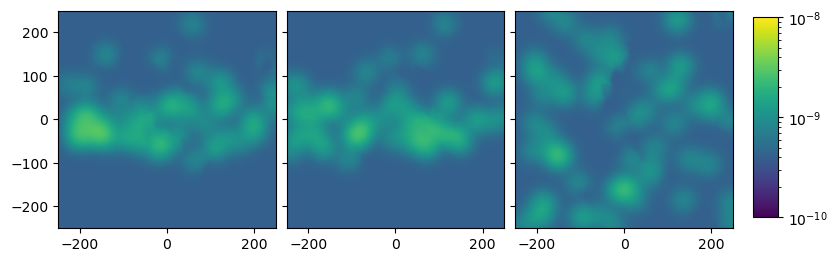

In [5]:
cell_volume_pc3 = (data["x_pc"][1]-data["x_pc"][0])**3
cell_volume_cm3 = cell_volume_pc3 * pc**3

cmap="plasma"

vmin=1e-10
vmax=1e-8

extent = [data["x_pc_bnds"][0], data["x_pc_bnds"][-1], data["x_pc_bnds"][0], data["x_pc_bnds"][-1]]

bg = ecr_uniform(data["n"].shape, 1.0)

models["ionization_streaming"] = ecr_ionization_model(
    bg, data["x_pc"], data["y_pc"], data["z_pc"],
    recent_SNe[:,1:4],
    data["f_ion"],
    fion0=0.1,
    amp_eVcc=10.0,
    sigma_pc=20.0,
    )

models["SN_blobs"] = add_gaussian_blobs(
    bg, data["x_pc"], data["y_pc"], data["z_pc"], recent_SNe[:,1:4],
    amp_eVcc=10.0,
    sigma_pc=20.0,
)

for name, ecr in models.items():

    if name == "ionization_streaming":
        fig, ax = plt.subplots(figsize=(10,4), ncols=3, sharey=True)
        im = ax[0].imshow(np.sum(ecr, axis=0).T, norm=LogNorm(vmin=vmin, vmax=vmax), extent=extent, origin="lower")
        im = ax[1].imshow(np.sum(ecr, axis=1).T, norm=LogNorm(vmin=vmin, vmax=vmax), extent=extent, origin="lower")
        im = ax[2].imshow(np.sum(ecr, axis=2),   norm=LogNorm(vmin=vmin, vmax=vmax), extent=extent, origin="lower")
    
        fig.subplots_adjust(right=0.8, wspace=0.05)
        cbar_ax = fig.add_axes([0.82, 0.25, 0.025, 0.5])
        fig.colorbar(im, cax=cbar_ax)


## $X_{cr}$ factor, effective $\gamma$

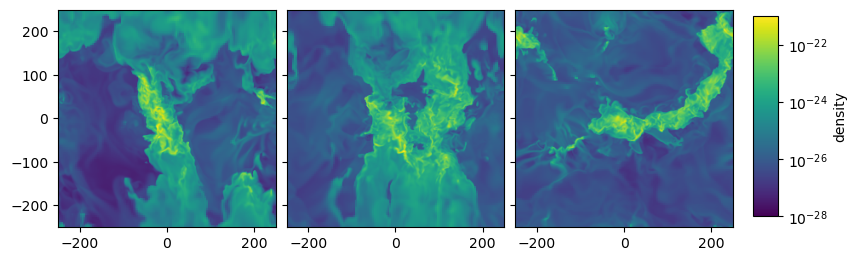

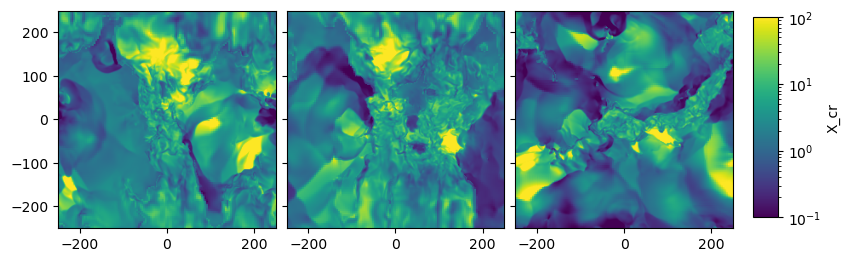

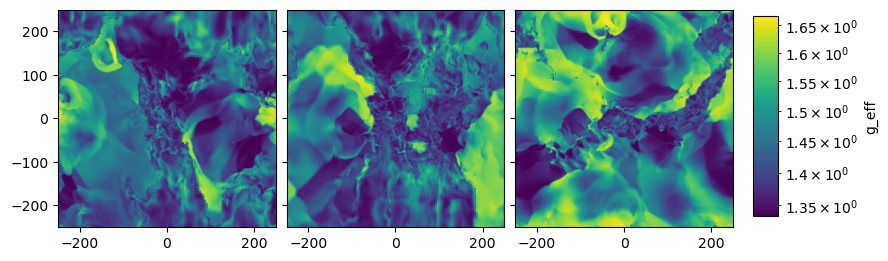

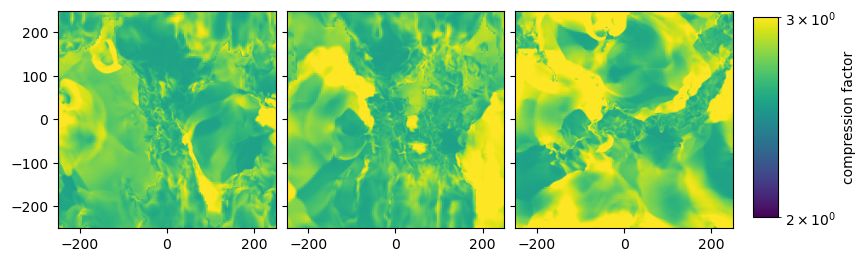

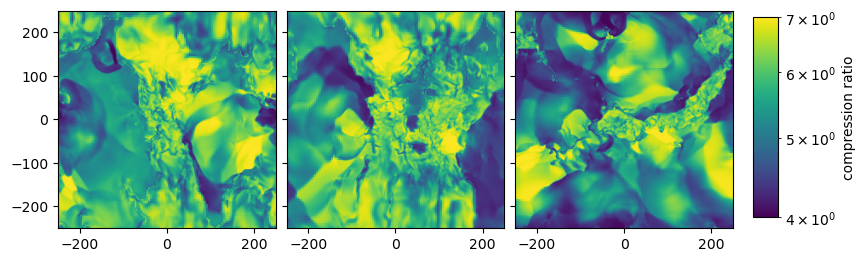

In [7]:
# compute the X_cr factor and the effective gamma
gamma    = 5./3.
gamma_cr = 4./3.

P_cr = (gamma_cr - 1.0)*ecr
X_cr = P_cr / data["P_th"]

g_eff = (P_cr*gamma_cr + data["P_th"]*gamma)/(P_cr + data["P_th"])

# compression factor
comp = np.power(2., g_eff)

# compression ratio
r = (g_eff + 1)/(g_eff - 1)

names = ["density", "X_cr", "g_eff", "compression factor", "compression ratio"]
for f, vmin, vmax, name in zip([data["rho"], X_cr, g_eff, comp, r], [1e-28,0.1,gamma_cr, 2, 4],[1e-21,100,gamma, 3, 7], names):
    fig, ax = plt.subplots(figsize=(10,4), ncols=3, sharey=True)
    im = ax[0].imshow((f[N//2,:,:]).T, norm=LogNorm(vmin=vmin, vmax=vmax), extent=extent, origin="lower")
    im = ax[1].imshow((f[:,N//2,:]).T, norm=LogNorm(vmin=vmin, vmax=vmax), extent=extent, origin="lower")
    im = ax[2].imshow((f[:,:,N//2]).T, norm=LogNorm(vmin=vmin, vmax=vmax), extent=extent, origin="lower")

    fig.subplots_adjust(right=0.8, wspace=0.05)
    cbar_ax = fig.add_axes([0.82, 0.25, 0.025, 0.5])
    fig.colorbar(im, cax=cbar_ax, label=name)


In [8]:
#

In [9]:
# separate phases
idx_all  = np.where(data["T"] > 0)
idx_cold = np.where(data["T"] < 300)
idx_warm = np.where((data["T"] > 300) & (data["T"] < 3e5))
idx_hot  = np.where(data["T"] > 3e5)

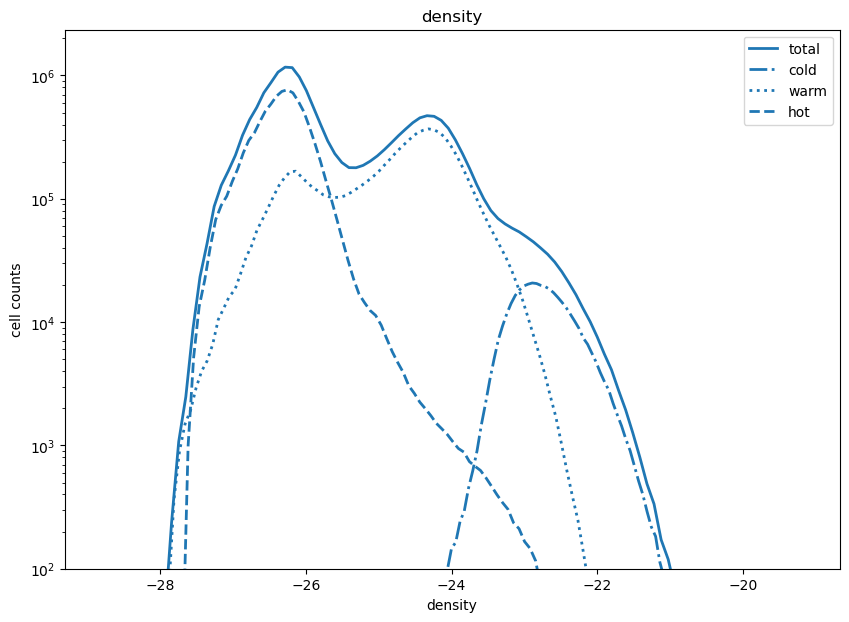

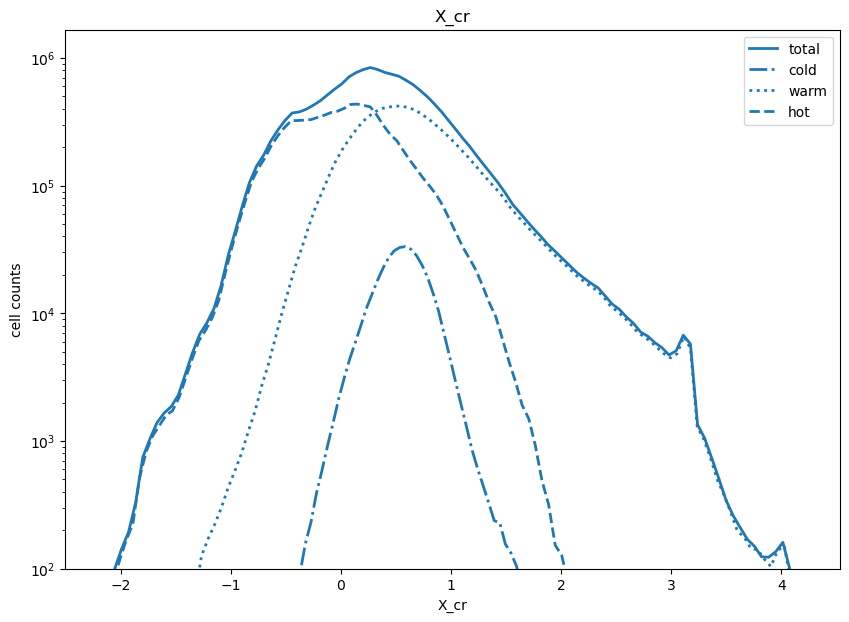

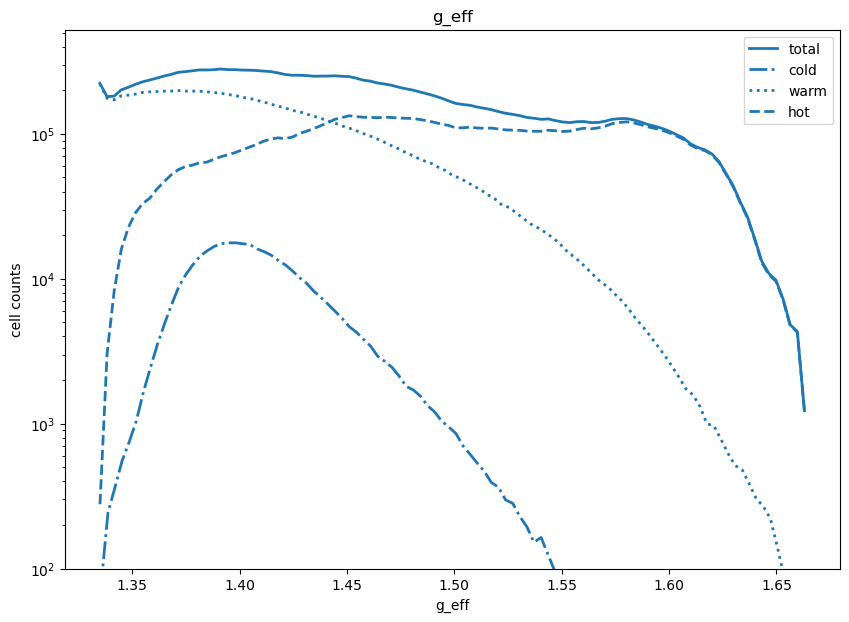

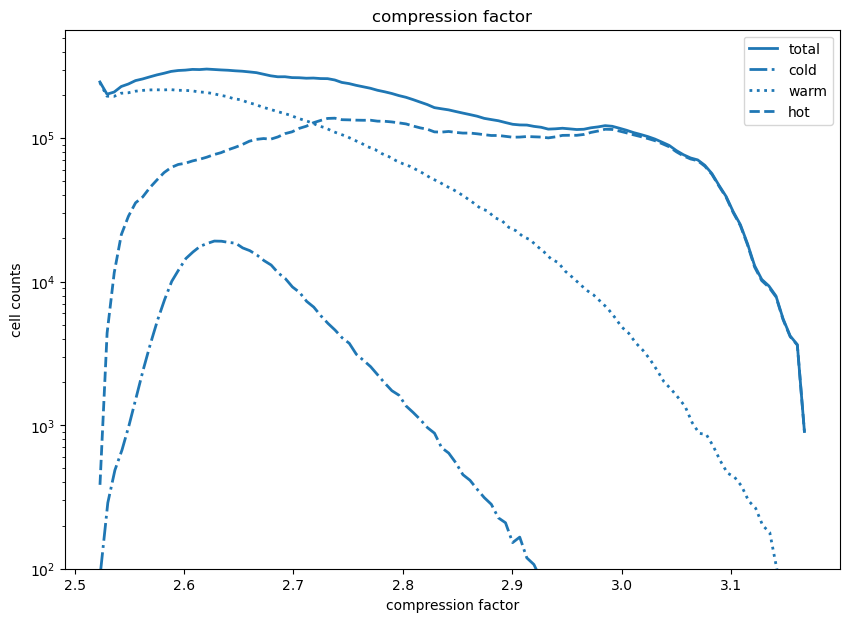

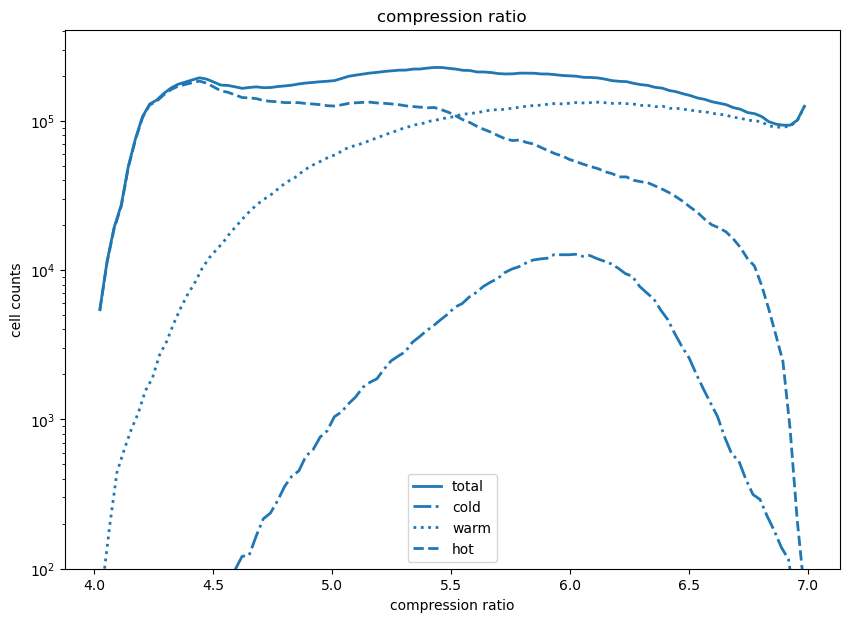

In [18]:
names = ["density", "X_cr", "g_eff", "compression factor", "compression ratio"]

for f, vmin, vmax, title in zip([np.log10(data["rho"]), np.log10(X_cr), g_eff, comp, r], [1e-28,0.1,gamma_cr, 2, 4],[1e-21,100,gamma, 3, 7], names):

    fig, ax = plt.subplots(figsize=(10,7))
    for ids, name, ls in zip([idx_all, idx_cold, idx_warm, idx_hot], \
                                 ["total", "cold", "warm", "hot"], \
                                 ["-", "-.", ":", "--"]):
        H, ed = np.histogram((f[ids]).flatten(), bins=100)
        ctr=0.5*(ed[1:]+ed[:-1])
        ax.plot(ctr, H, linewidth=2, label=name, ls=ls, color="C0")
        ax.legend()
    ax.set_title(title)
    ax.set_xlabel(title)
    ax.set_yscale("log")
    ax.set_ylim(100,None)
    ax.set_ylabel("cell counts")
    plt.show()